**Detecting Spam Emails**

In [22]:
#Importing Required Libraries
import numpy as np,pandas as pd
import matplotlib.pyplot as plt,seaborn as sns

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split as ttsplit
from keras.callbacks import EarlyStopping,ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
#Loading The Dataset
data=pd.read_csv('/content/spam_ham_dataset (1).csv')
print(data.shape)
data.head()

(5171, 4)


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


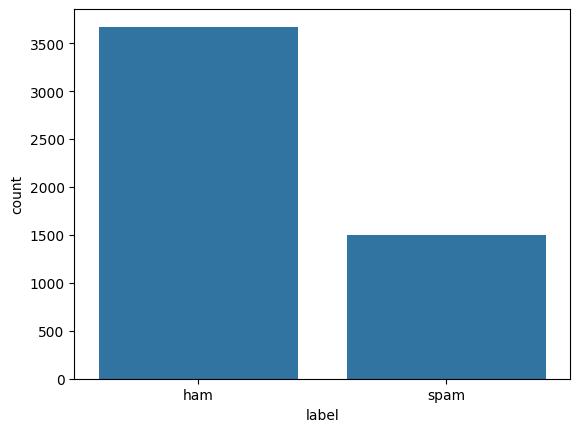

In [24]:
#Visualizing The Label Distribution
sns.countplot(x='label',data=data)
plt.show()

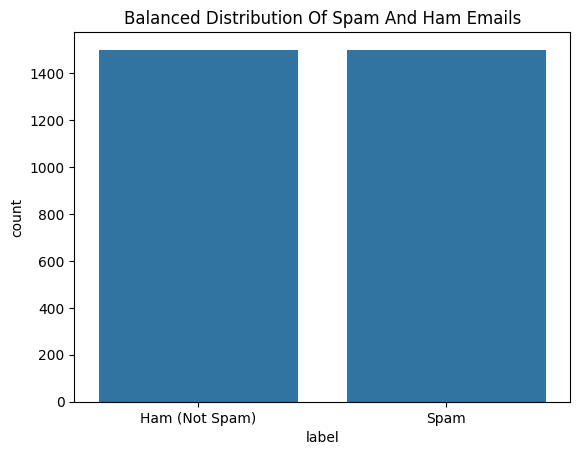

In [25]:
#Balancing The Dataset
ham=data[data['label']=='ham']
spam=data[data['label']=='spam']
#Downsampling 'ham' Label To Match 'spam' Label
ham_balance=ham.sample(n=len(spam),random_state=42)
#Combining Balanced Data
balanced=pd.concat([ham_balance,spam]).reset_index(drop=True)
#Visualizing The Balanced Dataset
sns.countplot(x='label',data=balanced)
plt.title("Balanced Distribution Of Spam And Ham Emails")
plt.xticks(ticks=[0,1],labels=['Ham (Not Spam)','Spam'])
plt.show()

In [26]:
#Cleaning The Text
balanced['text']=balanced['text'].str.replace('Subject','')
balanced.head()

'''
1.Punctuation Removal
2.Stopwords Removal
'''
def remove_puncs(txt):
  punc_lst=string.punctuation
  temp=str.maketrans('','',punc_lst)
  return txt.translate(temp)

def remove_stopwords(txt):
  stop_words=stopwords.words('english')
  imp_words=[]
  #Storing Important Words
  for i in str(txt).split():
    i=i.lower()
    if i not in stop_words:
      imp_words.append(i)
  out=" ".join(imp_words)
  return out

balanced['text']=balanced['text'].apply(lambda x:remove_puncs(x))
balanced.head()

balanced['text']=balanced['text'].apply(lambda x:remove_stopwords(x))
balanced.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


In [27]:
#Visualizing Word Cloud
def plot_wordcloud(data,t):
  mailcorpus=" ".join(data['text'])
  wc=WordCloud(background_color='black',
               max_words=100,
               width=800,
               height=400).generate(mailcorpus)
  plt.figure(figsize=(7,7))
  plt.imshow(wc,interpolation='bilinear')
  plt.title(f'WordCloud For{t} Emails',fontsize=15)
  plt.axis('off')
  plt.show()

  plot_wordcloud(balanced[balanced['label']=='ham'],t='Non-Spam')
  plot_wordcloud(balanced[balanced['label']=='spam'],t='Spam')


In [28]:
#Tokenization And Padding
xtrain,xtest,ytrain,ytest=ttsplit(balanced['text'],
                                  balanced['label'],
                                  test_size=0.2,
                                  random_state=42)
tkn=Tokenizer()
tkn.fit_on_texts(xtrain)
train_sq=tkn.texts_to_sequences(xtrain)
test_sq=tkn.texts_to_sequences(xtest)
maxlen=100
train_sq=pad_sequences(train_sq,maxlen=maxlen,
                       padding='post',truncating='post')
test_sq=pad_sequences(test_sq,maxlen=maxlen,
                      padding='post',truncating='post')
ytrain=(ytrain=='spam').astype(int)
ytest=(ytest=='spam').astype(int)

In [29]:
#Defining The Model
mdl=tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tkn.word_index)+1,
                              output_dim=32,input_length=maxlen),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(1,activation='sigmoid') #Output Layer
])
mdl.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    optimizer='adam',
    metrics=['accuracy']
)
mdl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Training The Model
es=EarlyStopping(patience=3,monitor='val_accuracy',restore_best_weights=True)
lr=ReduceLROnPlateau(patience=2,monitor='val_loss',factor=0.5,verbose=0)

hist=mdl.fit(
    train_sq,ytrain,
    validation_data=(test_sq,ytest),
    epochs=20,
    batch_size=32,
    callbacks=[lr,es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.5763 - loss: 0.6801 - val_accuracy: 0.7500 - val_loss: 0.5621 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9341 - loss: 0.2831 - val_accuracy: 0.9550 - val_loss: 0.2044 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9533 - loss: 0.1923 - val_accuracy: 0.9533 - val_loss: 0.1867 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9579 - loss: 0.1755 - val_accuracy: 0.9517 - val_loss: 0.2021 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9587 - loss: 0.1722 - val_accuracy: 0.9500 - val_loss: 0.1997 - learning_rate: 0.0010


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9550 - loss: 0.2044
Test Loss : 0.20438741147518158
Test Accuracy : 0.9549999833106995


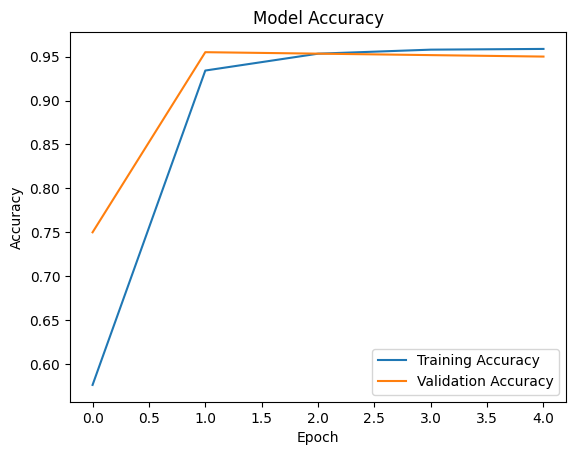

In [31]:
#Evaluating The Model
test_loss,test_acc=mdl.evaluate(test_sq,ytest)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_acc)

plt.plot(hist.history['accuracy'],label='Training Accuracy')
plt.plot(hist.history['val_accuracy'],label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()